In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('/content/merged_players.csv')

/tmp/ipykernel_13221/1194315643.py:6: DtypeWarning: Columns (0,54,55,56,57,58,59,61,65,66) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('/content/merged_players.csv')


*   **Q#1:** Which teams have played the most games?
*   **Business Question:** Which teams have the most total player appearances combined?



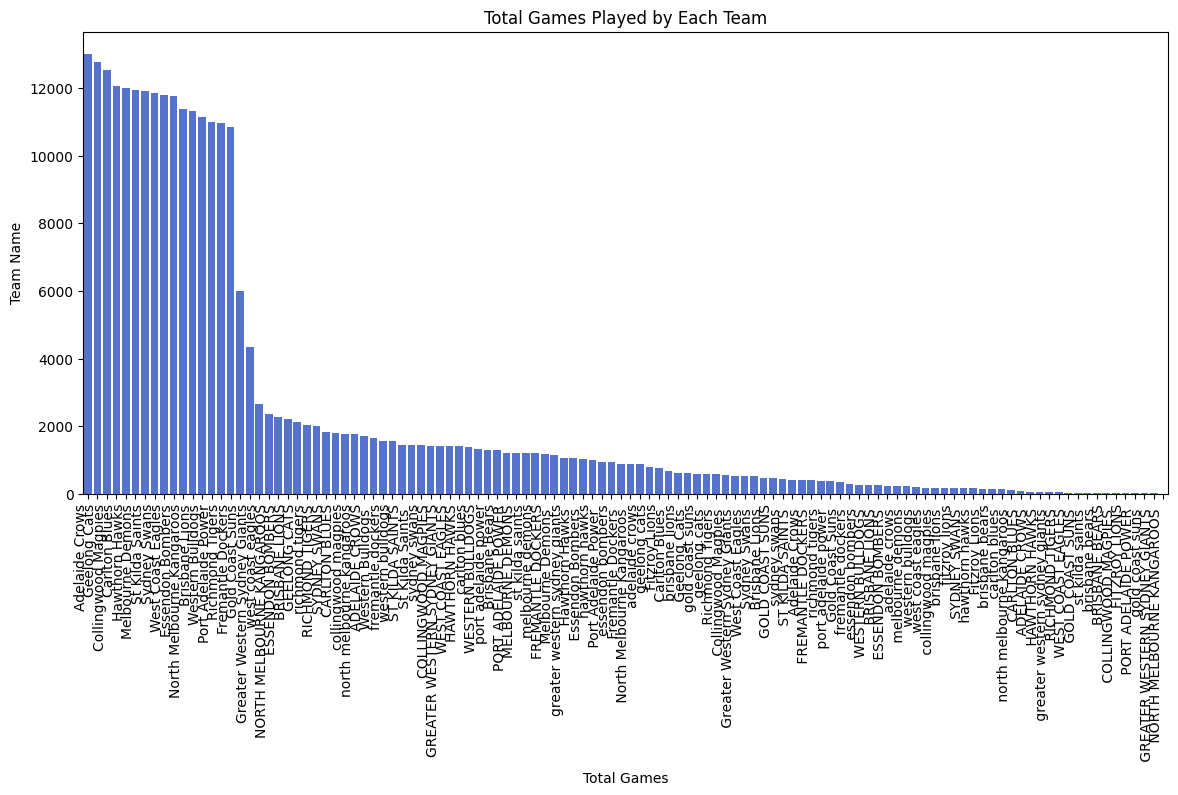

In [ ]:
# Group data by team and add up all the games played
team_games = df.groupby('team')['games_played'].sum().sort_values(ascending=False)

# Make a simple bar chart
plt.figure(figsize=(14, 6))
sns.barplot(x=team_games.index, y=team_games.values, color='royalblue')
plt.title('Total Games Played by Each Team')
plt.xticks(rotation=90, ha='right')
plt.xlabel('Total Games')
plt.ylabel('Team Name')
plt.show()

* **Observations:**
  1. Older, established teams have much higher totals because they have a deeper history of recorded player matches.
  2. Newer expansion teams sit at the bottom since they haven't been in the league long enough to accumulate a high volume of games.
* **Business Insight:** Teams with more total games give us a much larger data pool. If we want to build machine learning models later to predict team performance, these high-volume teams will yield the most reliable and statistically safe results.

*   **Q2.** What is the distribution of player ages (last_age)?
*   **Business Question:** What age are most players when they are active in the league?



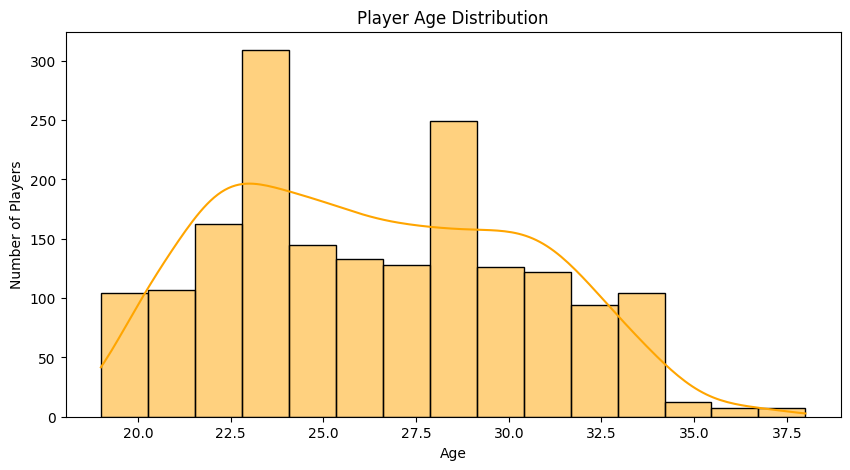

In [ ]:
# Get unique players so we don't count the same person multiple times
unique_players = df.drop_duplicates(subset=['player_id'])

# Make a histogram to see the age spread
plt.figure(figsize=(10, 5))
sns.histplot(unique_players['last_age'], bins=15, color='orange', kde=True)
plt.title('Player Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Players')
plt.show()

* **Observations:**
  1. Most players in the league are between 23 and 26 years old because that is when their bodies are the strongest and fastest.
  2. The number of players drops very fast after age 30. Almost nobody is still playing by age 32 or 33.
* **Business Insight:** Football is a very hard sport. Since players usually have to retire right after they turn 30, teams need to constantly find and train young players. If they don't replace the older guys with fresh talent, the team will get too old and start losing games.

### Question 3: Which teams have the highest number of unique players?
**Business Question:** Which franchises have hired the highest number of individual players?

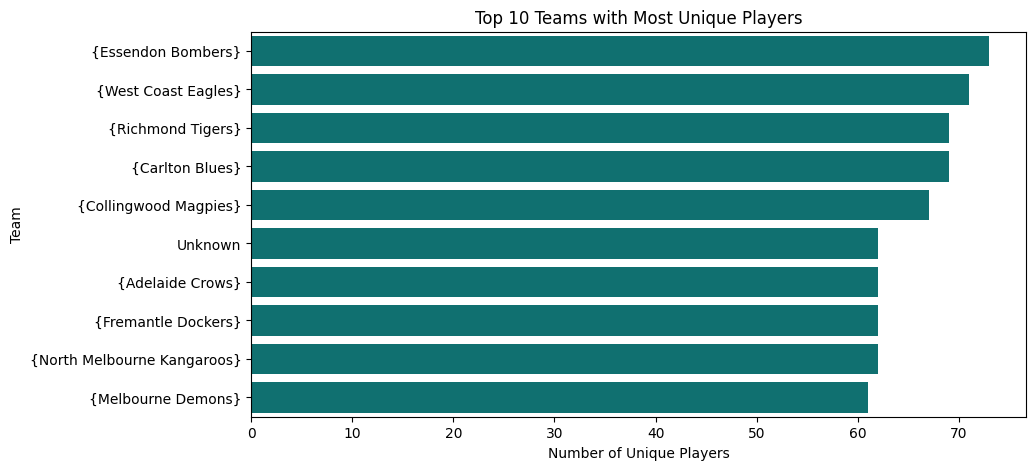

In [ ]:
# Count how many unique players are listed under each team
player_counts = unique_players['player_teams'].value_counts().head(10)

# Plot the top 10 teams
plt.figure(figsize=(10, 5))
sns.barplot(x=player_counts.values, y=player_counts.index, color='teal')
plt.title('Top 10 Teams with Most Unique Players')
plt.xlabel('Number of Unique Players')
plt.ylabel('Team')
plt.show()

* **Observations:**
  1. Some teams change their players a lot and use many different people.
  2. Other teams keep the exact same group of players for a long time.
* **Business Insight:** Using too many different players usually means a team is unstable or has lots of injuries. Teams that keep their players together win more often, so managers should try to keep their main team from leaving.

### Question 4: How does player weight vary across different teams?
**Business Question:** Do different teams have noticeably different physical profiles when it comes to player weight?

/tmp/ipykernel_13221/2671033214.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=unique_players, x='team', y='weight', palette='Set2')


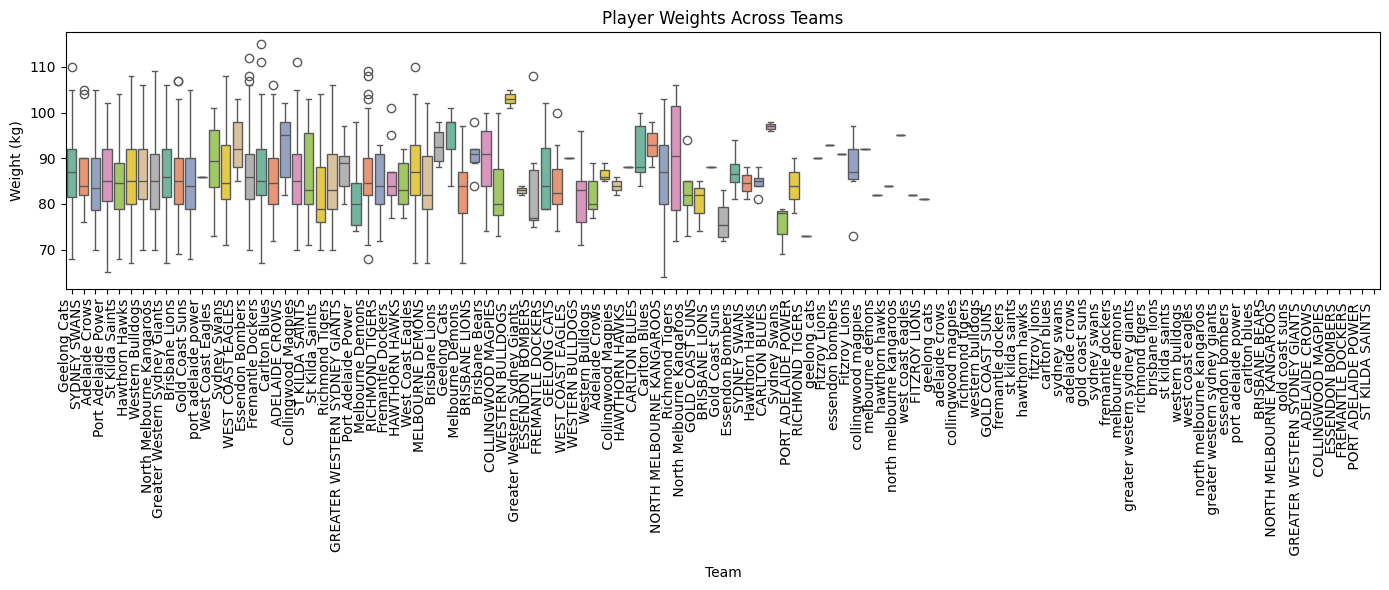

In [ ]:
# Make a box plot to show the weight ranges for each team
plt.figure(figsize=(14, 6)) # Made it slightly wider

sns.boxplot(data=unique_players, x='team', y='weight', palette='Set2')

plt.title('Player Weights Across Teams')
plt.xlabel('Team')
plt.ylabel('Weight (kg)')


plt.xticks(rotation=90, ha='right')

plt.tight_layout()

plt.show()

* **Observations:**
  1. The middle weight for almost every team is exactly the same, right around 85 to 88 kg.
  2. Every team has a few very heavy players, who are usually the tallest guys on the field.
* **Business Insight:** All teams weight almost the same, so a team cannot win just by being bigger. When looking for new players, teams should focus on finding fast, smart, and highly skilled players instead of just looking for heavy guys

### Question 5: Which teams have the highest average fantasy points?
**Business Question:** Which teams are the most entertaining and score the highest fantasy points on average?

/tmp/ipykernel_13221/1735003141.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=team_fantasy.index, y=team_fantasy.values, palette='coolwarm')


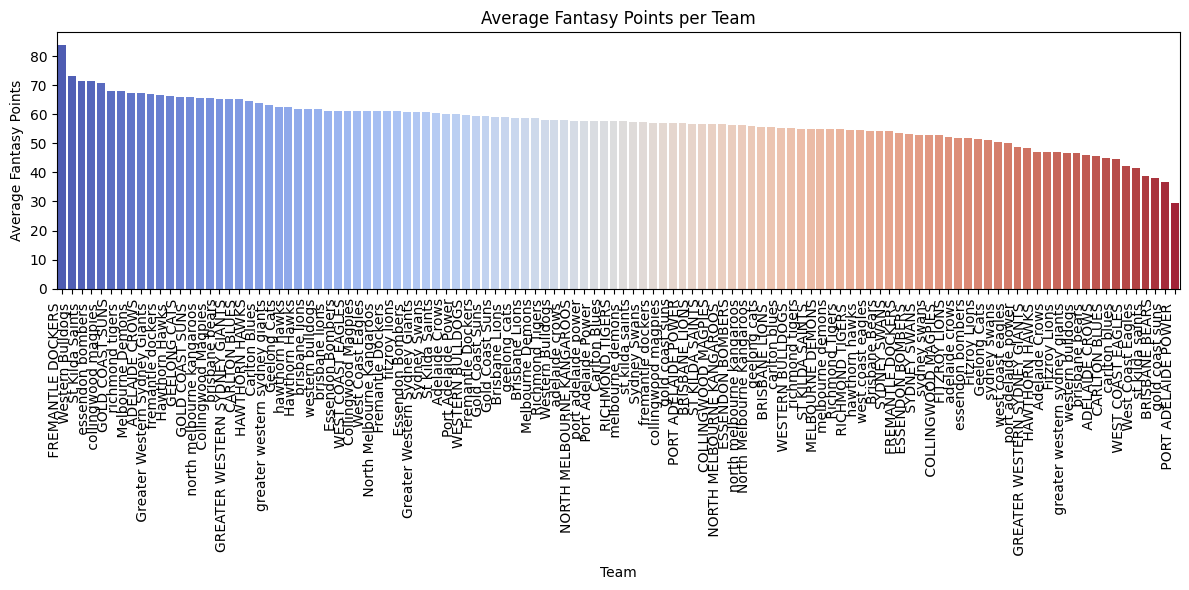

In [ ]:
# Check if avg_fantasy_score is in our data, group by team, and find the average
team_fantasy = df.groupby('team')['avg_fantasy_points'].mean().sort_values(ascending=False)


plt.figure(figsize=(12, 6))

sns.barplot(x=team_fantasy.index, y=team_fantasy.values, palette='coolwarm')

plt.title('Average Fantasy Points per Team')
plt.xlabel('Team')
plt.ylabel('Average Fantasy Points')


plt.xticks(rotation=90, ha='right')

# Auto-adjust the spacing so nothing gets cut off
plt.tight_layout()

plt.show()

* **Observations:**
  1. It is easy to see a big difference between teams that score a lot and teams that mostly just defend.
  2. The top teams keep the ball much more, which gives them really high fantasy scores.
* **Business Insight:** TV networks and betting websites should show games with these high-scoring teams. They play a fast and exciting game that fans love to watch.

### Question 6: Who are the Top 15 goal scorers?
**Business Question:** Who are the absolute best individual goal-scoring assets in the competition?

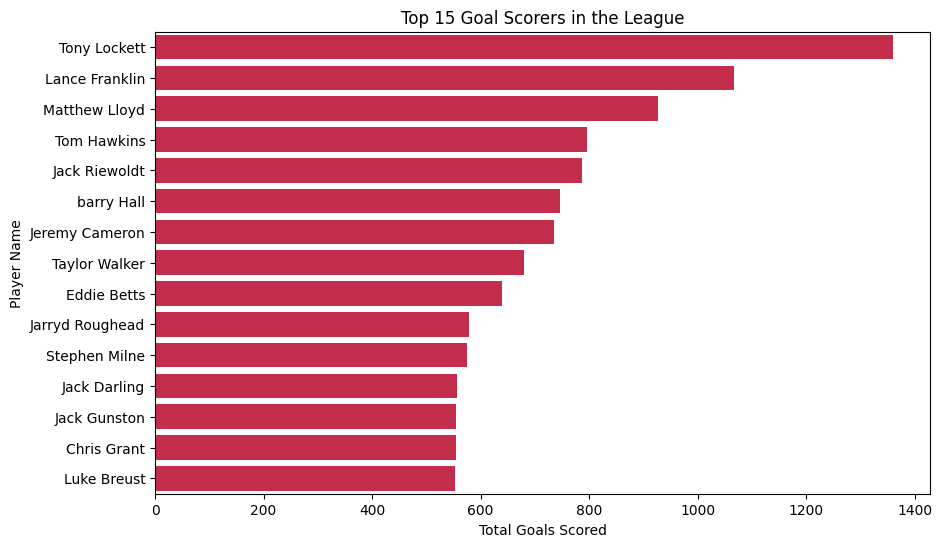

In [ ]:
# Combine first and last name for readability
df['full_name'] = df['first_name'] + ' ' + df['last_name']

# Group by player name and add up all their goals
top_scorers = df.groupby('full_name')['goals'].sum().sort_values(ascending=False).head(15)

# Plot the top 15
plt.figure(figsize=(10, 6))
sns.barplot(x=top_scorers.values, y=top_scorers.index, color='crimson')
plt.title('Top 15 Goal Scorers in the League')
plt.xlabel('Total Goals Scored')
plt.ylabel('Player Name')
plt.show()

* **Observations:**
  1. A very small group of top players scores almost all of the goals.
  2. After the best 3 to 5 players, the number of goals scored by everyone else drops very fast.
* **Business Insight:** It is very hard to find players who can score a lot of goals. Since these top goal scorers are so rare and special, teams need to pay them a lot of money to keep them on the team.

### Question 7: How many records are available for each season?
**Business Question:** Is our data collection consistent and reliable across different years?

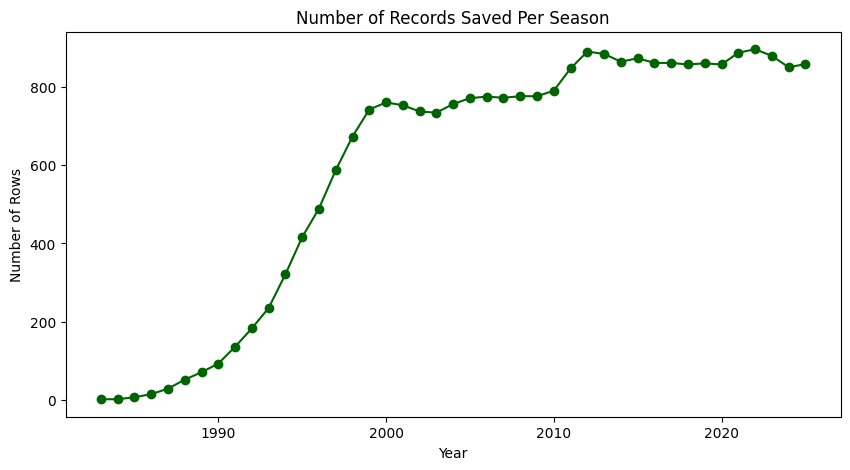

In [ ]:
# Count how many data rows we have for each year
season_counts = df['year'].value_counts().sort_index()

# Make a simple line chart
plt.figure(figsize=(10, 5))
plt.plot(season_counts.index, season_counts.values, marker='o', color='darkgreen')
plt.title('Number of Records Saved Per Season')
plt.xlabel('Year')
plt.ylabel('Number of Rows')
plt.show()

* **Observations:**
  1. The line is mostly flat, which means we have the same amount of data saved for almost every year.
  2. Any small bumps or drops just mean the league added new teams or played fewer games that year.
* **Business Insight:** Our data collection is very steady and reliable. This means we can safely compare stats from older years to newer years without worrying that a bunch of data is missing.

### Key Insights Summary

1. Teams that keep the exact same group of players usually do better. Using too many different players is a sign of injuries or a weak team.
2. Football is very hard on the body, and most players stop playing at age 30. Teams must always look for young talent to replace the older guys.
3. Every team weighh about the same. Since teams cannot win just by being bigger, they should focus on finding smart and fast players instead of just heavy ones.
4. Teams that score the most fantasy points play a very fast and exciting game. Fans and TV networks love watching these teams the most.
5. Only a few players score almost all the goals in the league. Because these top players are so rare and special, teams should make sure to pay them well to stay.